---
title: "Boosting Model 2"
author: Karisa Kopecek
date: today
format:
  html:
    embed-resources: true
    echo: true
---

## Methodology

**Model: LightGBM**
**Target:** `Irrigation_Need` (Low / Medium / High)  
**Metric:** Weighted F1 because of imbalanced data (see earlier EDA file done)
**Goal:** Test how different hyperparameter configurations actually change LightGBM performance and continue to tune with Optuna

## Setup and loading data and features

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import lightgbm as lgb
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED   = 42
TARGET = 'Irrigation_Need'
ORDER  = ['Low', 'Medium', 'High']
CAT_COLS = ['Soil_Type','Crop_Type','Crop_Growth_Stage','Season',
            'Irrigation_Type','Water_Source','Mulching_Used','Region']

In [2]:
#loading data and then choosing same features as previously used
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

for df in [train, test]:
    df['stage_mulch']   = df['Crop_Growth_Stage'].astype(str) + '_' + df['Mulching_Used'].astype(str)
    # interaction term that consistently ranked as the most useful engineered feature

    df['stress_index']  = (df['Temperature_C'] + df['Wind_Speed_kmh']) / (df['Soil_Moisture'] + 1)
    # high temp + wind + low moisture → higher irrigation demand

    df['water_deficit'] = df['Temperature_C'] / (df['Rainfall_mm'] / 100 + 1)
    # evapotranspiration proxy

FEAT_CATS = CAT_COLS + ['stage_mulch']

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
train[FEAT_CATS] = oe.fit_transform(train[FEAT_CATS])
test[FEAT_CATS]  = oe.transform(test[FEAT_CATS])

le = LabelEncoder()
y  = le.fit_transform(train[TARGET])

FEAT_COLS = [c for c in train.columns if c not in ['id', TARGET]]
X      = train[FEAT_COLS].values
X_test = test[FEAT_COLS].values

print(f'Features: {len(FEAT_COLS)}, Train rows: {len(X):,}')

Features: 22, Train rows: 630,000


In [3]:
# using the same CV method as in previous notebooks to keep results consistant
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

sample_idx = np.random.RandomState(SEED).choice(len(X), 30000, replace=False)
X_s, y_s   = X[sample_idx], y[sample_idx]

X_tr, X_val, y_tr, y_val = train_test_split(
    X_s, y_s, test_size=0.2, stratify=y_s, random_state=SEED)

print(f'CV sample: {len(X_s):,} rows, hold-out val: {len(X_val):,} rows')

CV sample: 30,000 rows, hold-out val: 6,000 rows


## Hyperparameters

Three hyperparameter configurations are tested before moving on to Optuna for tuning. While additional setups were explored, these three were selected because they performed the best and kept the analysis concise.

**Config A (Few Leaves and High Learning Rate)**
num_leaves=15, max_depth=4, learning_rate=0.3, n_estimators=100, subsample=1.0, colsample_bytree=1.0, min_child_samples=20.
This configuration intentionally keeps the model simple, with a small number of leaves and shallow depth. The higher learning rate compensates for the lower number of estimators, allowing faster learning. With no subsampling applied, this serves as a baseline to evaluate how a low-complexity model performs on the dataset.

**Config B (Deeper and Aggressive Subsampling)**
num_leaves=80, max_depth=8, learning_rate=0.1, n_estimators=400, subsample=0.65, colsample_bytree=0.7, min_child_samples=30.
This configuration increases model complexity through deeper trees and more leaves to capture richer feature interactions. To counteract potential overfitting, aggressive row and column subsampling (65% and 70%) is applied. This tests whether subsampling alone is sufficient to control variance while benefiting from a more expressive model.

**Config C (Explicit Regularization)**
num_leaves=80, max_depth=8, learning_rate=0.1, n_estimators=400, subsample=0.65, colsample_bytree=0.7, min_child_samples=30, reg_alpha=0.2, reg_lambda=1.5, min_split_gain=0.1.
This configuration builds directly on Config B by introducing explicit regularization. L1 (reg_alpha) and L2 (reg_lambda) penalties are added, along with min_split_gain, which enforces a minimum loss reduction before a split is made (similar to gamma in XGBoost). This setup evaluates whether adding regularization on top of subsampling further improves generalization performance.


In [4]:
configs = {
    'Config A (Few Leaves/High LR)': dict(
        num_leaves=15, max_depth=4,
        learning_rate=0.3, n_estimators=100,
        subsample=1.0, colsample_bytree=1.0,
        min_child_samples=20
        # intentionally simple: tests the lower end of complexity
    ),
    'Config B (Deeper + Aggressive Subsample)': dict(
        num_leaves=80, max_depth=8,
        learning_rate=0.1, n_estimators=400,
        subsample=0.65, colsample_bytree=0.7,
        min_child_samples=30
        # more leaves + aggressive subsampling as variance reduction
    ),
    'Config C (Explicit Regularization)': dict(
        num_leaves=80, max_depth=8,
        learning_rate=0.1, n_estimators=400,
        subsample=0.65, colsample_bytree=0.7,
        min_child_samples=30,
        reg_alpha=0.2, reg_lambda=1.5,
        min_split_gain=0.1
        # same base as B but adds L1, L2, and min_split_gain
        # min_split_gain requires a minimum loss reduction to make a split,
        # similar to XGBoost's gamma — tests whether explicit penalties
        # on top of subsampling squeeze out any additional improvement
    ),
}

config_results = {}

for name, params in configs.items():
    model = lgb.LGBMClassifier(
        **params,
        objective='multiclass', class_weight='balanced',
        n_jobs=1, random_state=SEED, verbose=-1
    )
    scores = cross_val_score(model, X_s, y_s, cv=CV,
                             scoring='f1_weighted', n_jobs=1)
    config_results[name] = (scores.mean(), scores.std())
    print(f'{name}: {scores.mean():.4f} +/- {scores.std():.4f}')

Config A (Few Leaves/High LR): 0.9814 +/- 0.0006
Config B (Deeper + Aggressive Subsample): 0.9815 +/- 0.0005
Config C (Explicit Regularization): 0.9810 +/- 0.0003


## Adding in optuna tuning

Optuna is then used to run 50 trials, each testing different hyperparameter combos. Unlike the manual configs, where parameters were adjusted more individually, Optuna tunes everything together and finds the best performing combos.

The search ranges are based on earlier results. **max_depth** is set to 6–10 since deeper trees performed better, and **num_leaves** (40–120) allows more complex models. Subsampling is limited to 0.65–0.85, as more aggressive values helped reduce overfitting. **learning_rate** (0.05–0.2) and **n_estimators** (300–600) balance stability and model strength, while **min_child_samples** (20–60) helps control leaf growth. Regularization is included but kept small (**reg_alpha** 0–0.3, **reg_lambda** 0–1.5) since heavy penalties didn’t help much before.


In [5]:
def lgb_objective(trial):
    params = {
        'num_leaves':        trial.suggest_int('num_leaves', 40, 120),
        'max_depth':         trial.suggest_int('max_depth', 6, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.05, 0.2),
        'n_estimators':      trial.suggest_int('n_estimators', 300, 600),
        'subsample':         trial.suggest_float('subsample', 0.65, 0.85),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.65, 0.85),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 60),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0, 0.3),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0, 1.5),
    }
    model = lgb.LGBMClassifier(
        **params,
        objective='multiclass', class_weight='balanced',
        n_jobs=1, random_state=SEED, verbose=-1
    )
    # same CV function as manual configs so scores are directly comparable
    scores = cross_val_score(model, X_s, y_s, cv=CV,
                             scoring='f1_weighted', n_jobs=1)
    return scores.mean()

study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(lgb_objective, n_trials=50)

print(f'Best LightGBM params: {study_lgb.best_params}')
print(f'Best CV F1:           {study_lgb.best_value:.4f}')

Best LightGBM params: {'num_leaves': 91, 'max_depth': 6, 'learning_rate': 0.13113474949341417, 'n_estimators': 462, 'subsample': 0.7311103817723412, 'colsample_bytree': 0.814931087427937, 'min_child_samples': 29, 'reg_alpha': 0.056154289537498764, 'reg_lambda': 0.03618971247938263}
Best CV F1:           0.9822


In [6]:
lgb_best = lgb.LGBMClassifier(
    **study_lgb.best_params,
    objective='multiclass', class_weight='balanced',
    n_jobs=1, random_state=SEED, verbose=-1
)
scores = cross_val_score(lgb_best, X_s, y_s, cv=CV,
                         scoring='f1_weighted', n_jobs=1)
config_results['Config D (Optuna)'] = (scores.mean(), scores.std())
print(f'Config D (Optuna): {scores.mean():.4f} +/- {scores.std():.4f}')

Config D (Optuna): 0.9822 +/- 0.0005


## Hyperparameter configuration comparison plot



=== LightGBM Config Summary ===
Config                                    CV F1      Std
----------------------------------------------------------
Config A (Few Leaves/High LR)          0.9814   0.0006
Config B (Deeper + Aggressive Subsample) 0.9815   0.0005
Config C (Explicit Regularization)     0.9810   0.0003
Config D (Optuna)                      0.9822   0.0005


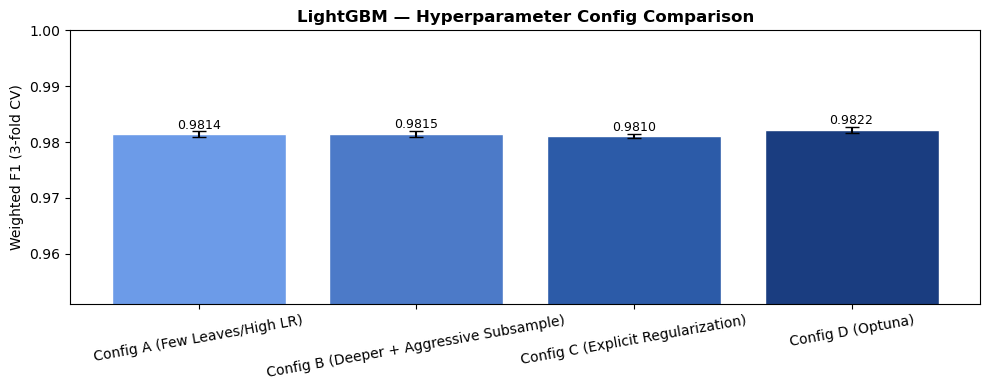

In [7]:
print('\n=== LightGBM Config Summary ===')
print(f'{"Config":<38} {"CV F1":>8}  {"Std":>7}')
print('-' * 58)
for name, (mean, std) in config_results.items():
    print(f'{name:<38} {mean:.4f}   {std:.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
names  = list(config_results.keys())
means  = [config_results[n][0] for n in names]
stds   = [config_results[n][1] for n in names]
colors = ['#6C9BE8', '#4C7AC8', '#2C5BA8', '#1A3D80']

bars = ax.bar(names, means, yerr=stds, capsize=5,
              color=colors, edgecolor='white')
ax.set_ylim(min(means) - 0.03, 1.0)
ax.set_ylabel('Weighted F1 (3-fold CV)')
ax.set_title('LightGBM — Hyperparameter Config Comparison', fontweight='bold')
ax.tick_params(axis='x', rotation=10)

for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

## Best Model Further Evaluation


In [8]:
lgb_eval = lgb.LGBMClassifier(
    **study_lgb.best_params,
    objective='multiclass', class_weight='balanced',
    n_jobs=1, random_state=SEED, verbose=-1
)
lgb_eval.fit(X_tr, y_tr,
             eval_set=[(X_val, y_val)],
             callbacks=[lgb.early_stopping(50, verbose=False),
                        lgb.log_evaluation(-1)])
y_pred = lgb_eval.predict(X_val)

print(classification_report(y_val, y_pred, target_names=le.classes_))
print(f'Weighted F1 : {f1_score(y_val, y_pred, average="weighted"):.4f}')
print(f'Macro   F1  : {f1_score(y_val, y_pred, average="macro"):.4f}')

              precision    recall  f1-score   support

        High       0.93      0.95      0.94       205
         Low       0.98      0.99      0.99      3505
      Medium       0.98      0.97      0.97      2290

    accuracy                           0.98      6000
   macro avg       0.96      0.97      0.97      6000
weighted avg       0.98      0.98      0.98      6000

Weighted F1 : 0.9806
Macro   F1  : 0.9663


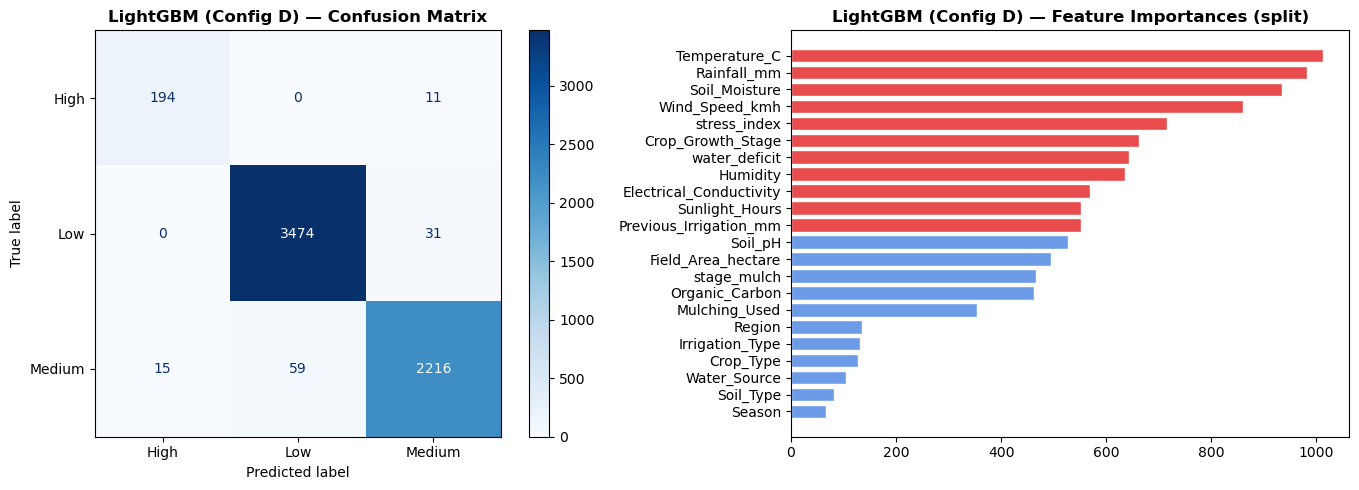

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_val, y_pred),
    display_labels=le.classes_
).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('LightGBM (Config D) — Confusion Matrix', fontweight='bold')

imp = pd.Series(lgb_eval.feature_importances_, index=FEAT_COLS).sort_values()
c = ['#E84C4C' if v > imp.median() else '#6C9BE8' for v in imp]
axes[1].barh(imp.index, imp.values, color=c, edgecolor='white')
axes[1].set_title('LightGBM (Config D) — Feature Importances (split)', fontweight='bold')

plt.tight_layout(); plt.show()

## Kaggle Submission


In [10]:
# LightGBM is fast enough to train on the full dataset (unlike RF)
lgb_sub = lgb.LGBMClassifier(
    **study_lgb.best_params,
    objective='multiclass', class_weight='balanced',
    n_jobs=1, random_state=SEED, verbose=-1
)
lgb_sub.fit(X, y)

submission = pd.DataFrame({
    'id':   test['id'],
    TARGET: le.inverse_transform(lgb_sub.predict(X_test))
})
submission.to_csv('submission_lgb_optuna.csv', index=False)
print('Saved: submission_lgb_optuna.csv')
print(submission[TARGET].value_counts())

Saved: submission_lgb_optuna.csv
Irrigation_Need
Low       159631
Medium    101302
High        9067
Name: count, dtype: int64
